In [2]:
# Barrier select analysis for RQ3 - inspection of context responses
import pandas as pd
from pathlib import Path
df_ctx = pd.read_csv('../2_context/contextResponses/contextBarrierSelectResponses.csv')

df_ctx.info()

# count unique iterations
print(f"Unique iterations: {df_ctx['iteration'].nunique()}")

# keep only 50 iterations for context responses
df_ctx = df_ctx[df_ctx['iteration'] < 50]

# create output directory
output_dir = Path('barriers-ctx-anchor-working')
output_dir.mkdir(parents=True, exist_ok=True)

# save remaining
df_ctx.to_csv(output_dir / 'contextBarrierSelectResponses_50.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   row_id             3240 non-null   object
 1   base_model         3240 non-null   object
 2   variant_id         3240 non-null   object
 3   model              3240 non-null   object
 4   barrier_id         3240 non-null   int64 
 5   model_barrier_id   3240 non-null   int64 
 6   official_label     3240 non-null   object
 7   model_label        3240 non-null   object
 8   label_status       3240 non-null   object
 9   barrier_id_status  3240 non-null   object
 10  is_hallucinated    3240 non-null   bool  
 11  iteration          3240 non-null   int64 
 12  timestamp          3240 non-null   object
 13  truncated          3240 non-null   object
dtypes: bool(1), int64(3), object(10)
memory usage: 332.4+ KB
Unique iterations: 54


In [3]:
# Barrier select analysis for RQ3 - inspection of anchor responses
import pandas as pd
from pathlib import Path
df_anchor = pd.read_csv('../3_anchor/anchorResponses/anchorBarrierSelectResponses.csv')

df_anchor.info()

# count unique iterations per arm there are 4 arms in the anchor responses
print(f"Unique iterations: {df_anchor['iteration'].nunique()}")
for arm in df_anchor['anchor_type'].unique():
    print(f"Unique iterations for arm {arm}: {df_anchor[df_anchor['anchor_type'] == arm]['iteration'].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   row_id             2400 non-null   object 
 1   base_model         2400 non-null   object 
 2   variant_id         2400 non-null   object 
 3   model              2400 non-null   object 
 4   barrier_id         2400 non-null   int64  
 5   model_barrier_id   2400 non-null   int64  
 6   official_label     2400 non-null   object 
 7   model_label        2400 non-null   object 
 8   label_status       2400 non-null   object 
 9   barrier_id_status  2400 non-null   object 
 10  is_hallucinated    2400 non-null   bool   
 11  similarity         2400 non-null   float64
 12  iteration          2400 non-null   int64  
 13  timestamp          2400 non-null   object 
 14  truncated          2400 non-null   object 
 15  condition          2400 non-null   object 
 16  anchor_type        2400 

In [4]:
# cell3: merging zeroshot and context data
import pandas as pd

# load data
df_ctx = pd.read_csv('barriers-ctx-anchor-working/contextBarrierSelectResponses_50.csv')
df_anchor = pd.read_csv('../3_anchor/anchorResponses/anchorBarrierSelectResponses.csv')

# define source and condition
df_ctx['condition'] = 'context'
df_anchor['condition'] = 'anchor'

# exact columns to keep
columns_to_keep = ['row_id', 'variant_id', 'base_model', 'model', 'barrier_id', 'official_label', 'condition', 'anchor_type','anchor_level', 'iteration']

# add any missing columns
for column in columns_to_keep:
    if column not in df_ctx.columns: df_ctx[column] = pd.NA
    if column not in df_anchor.columns: df_anchor[column] = pd.NA

# combine the dataframes
df_combined = pd.concat([df_ctx[columns_to_keep], df_anchor[columns_to_keep]], ignore_index=True)

# save combined dataframe
df_combined.to_csv(output_dir / 'barriers-ctx-anchor-responses.csv', index=False)


In [5]:
df_combined = pd.read_csv('barriers-ctx-anchor-working/barriers-ctx-anchor-responses.csv')

df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   row_id          5400 non-null   object
 1   variant_id      5400 non-null   object
 2   base_model      5400 non-null   object
 3   model           5400 non-null   object
 4   barrier_id      5400 non-null   int64 
 5   official_label  5400 non-null   object
 6   condition       5400 non-null   object
 7   anchor_type     2400 non-null   object
 8   anchor_level    1200 non-null   object
 9   iteration       5400 non-null   int64 
dtypes: int64(2), object(8)
memory usage: 422.0+ KB


In [1]:
# Generate the RQ3 JSI LaTeX table from the R-script results

from pathlib import Path
import pandas as pd

input_path = Path(
    "barriers-ctx-anchor-working/"
    "rq3_top5_jaccard_table.csv"
)

results = pd.read_csv(input_path)

required_columns = [
    "family",
    "model_label",
    "jaccard_pooled",
    "jaccard_word",
    "jaccard_example",
    "jaccard_low_numeric",
    "jaccard_high_numeric",
]

missing_columns = set(required_columns) - set(results.columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {sorted(missing_columns)}"
    )

if results["family"].duplicated().any():
    raise ValueError(
        "The input contains more than one row for a model family."
    )

family_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

table = (
    results[required_columns]
    .set_index("family")
    .reindex(family_order)
    .reset_index()
)

if table["model_label"].isna().any():
    missing_families = table.loc[
        table["model_label"].isna(),
        "family"
    ].tolist()

    raise ValueError(
        f"Missing results for model families: {missing_families}"
    )

table = (
    table.drop(columns="family")
    .rename(
        columns={
            "model_label": "Model",
            "jaccard_pooled":
                r"$JSI(\mathrm{Ctx},\mathrm{Anchors})$",
            "jaccard_word":
                r"$JSI(\mathrm{Ctx},\mathrm{Word})$",
            "jaccard_example":
                r"$JSI(\mathrm{Ctx},\mathrm{Example})$",
            "jaccard_low_numeric":
                r"$JSI(\mathrm{Ctx},\mathrm{Low\text{-}num})$",
            "jaccard_high_numeric":
                r"$JSI(\mathrm{Ctx},\mathrm{High\text{-}num})$",
        }
    )
)

latex_table = table.to_latex(
    index=False,
    escape=False,
    column_format="lccccc",
    caption="JSI on top-5 barriers---anchors vs. context",
    label="tab:rq3_jaccard_top5",
    float_format=lambda value: f"{value:.3f}",
    position="ht",
)
# save the LaTeX table to a file
output_path = Path("barriers-ctx-anchor-working/rq3-jaccard-top5.tex")
output_path.write_text(latex_table)

print(latex_table)

\begin{table}[ht]
\caption{JSI on top-5 barriers---anchors vs. context}
\label{tab:rq3_jaccard_top5}
\begin{tabular}{lccccc}
\toprule
Model & $JSI(\mathrm{Ctx},\mathrm{Anchors})$ & $JSI(\mathrm{Ctx},\mathrm{Word})$ & $JSI(\mathrm{Ctx},\mathrm{Example})$ & $JSI(\mathrm{Ctx},\mathrm{Low\text{-}num})$ & $JSI(\mathrm{Ctx},\mathrm{High\text{-}num})$ \\
\midrule
Phi4 & 1.000 & 0.667 & 0.667 & 1.000 & 0.667 \\
Gemma3:12B & 0.667 & 0.667 & 0.667 & 0.667 & 0.667 \\
Mistral & 1.000 & 1.000 & 1.000 & 1.000 & 1.000 \\
LLaMa-Pro & 1.000 & 1.000 & 1.000 & 1.000 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}



RQ3 rank-based barrier slopegraph saved to:
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/barriers-ctx-anchor-working/rq3-top5-barrier-rank-slopegraph.png
/Users/HP/Documents/second-publication/current-analysis/re-run/rq3-rerun/barriers-ctx-anchor-working/rq3-top5-barrier-rank-slopegraph.eps


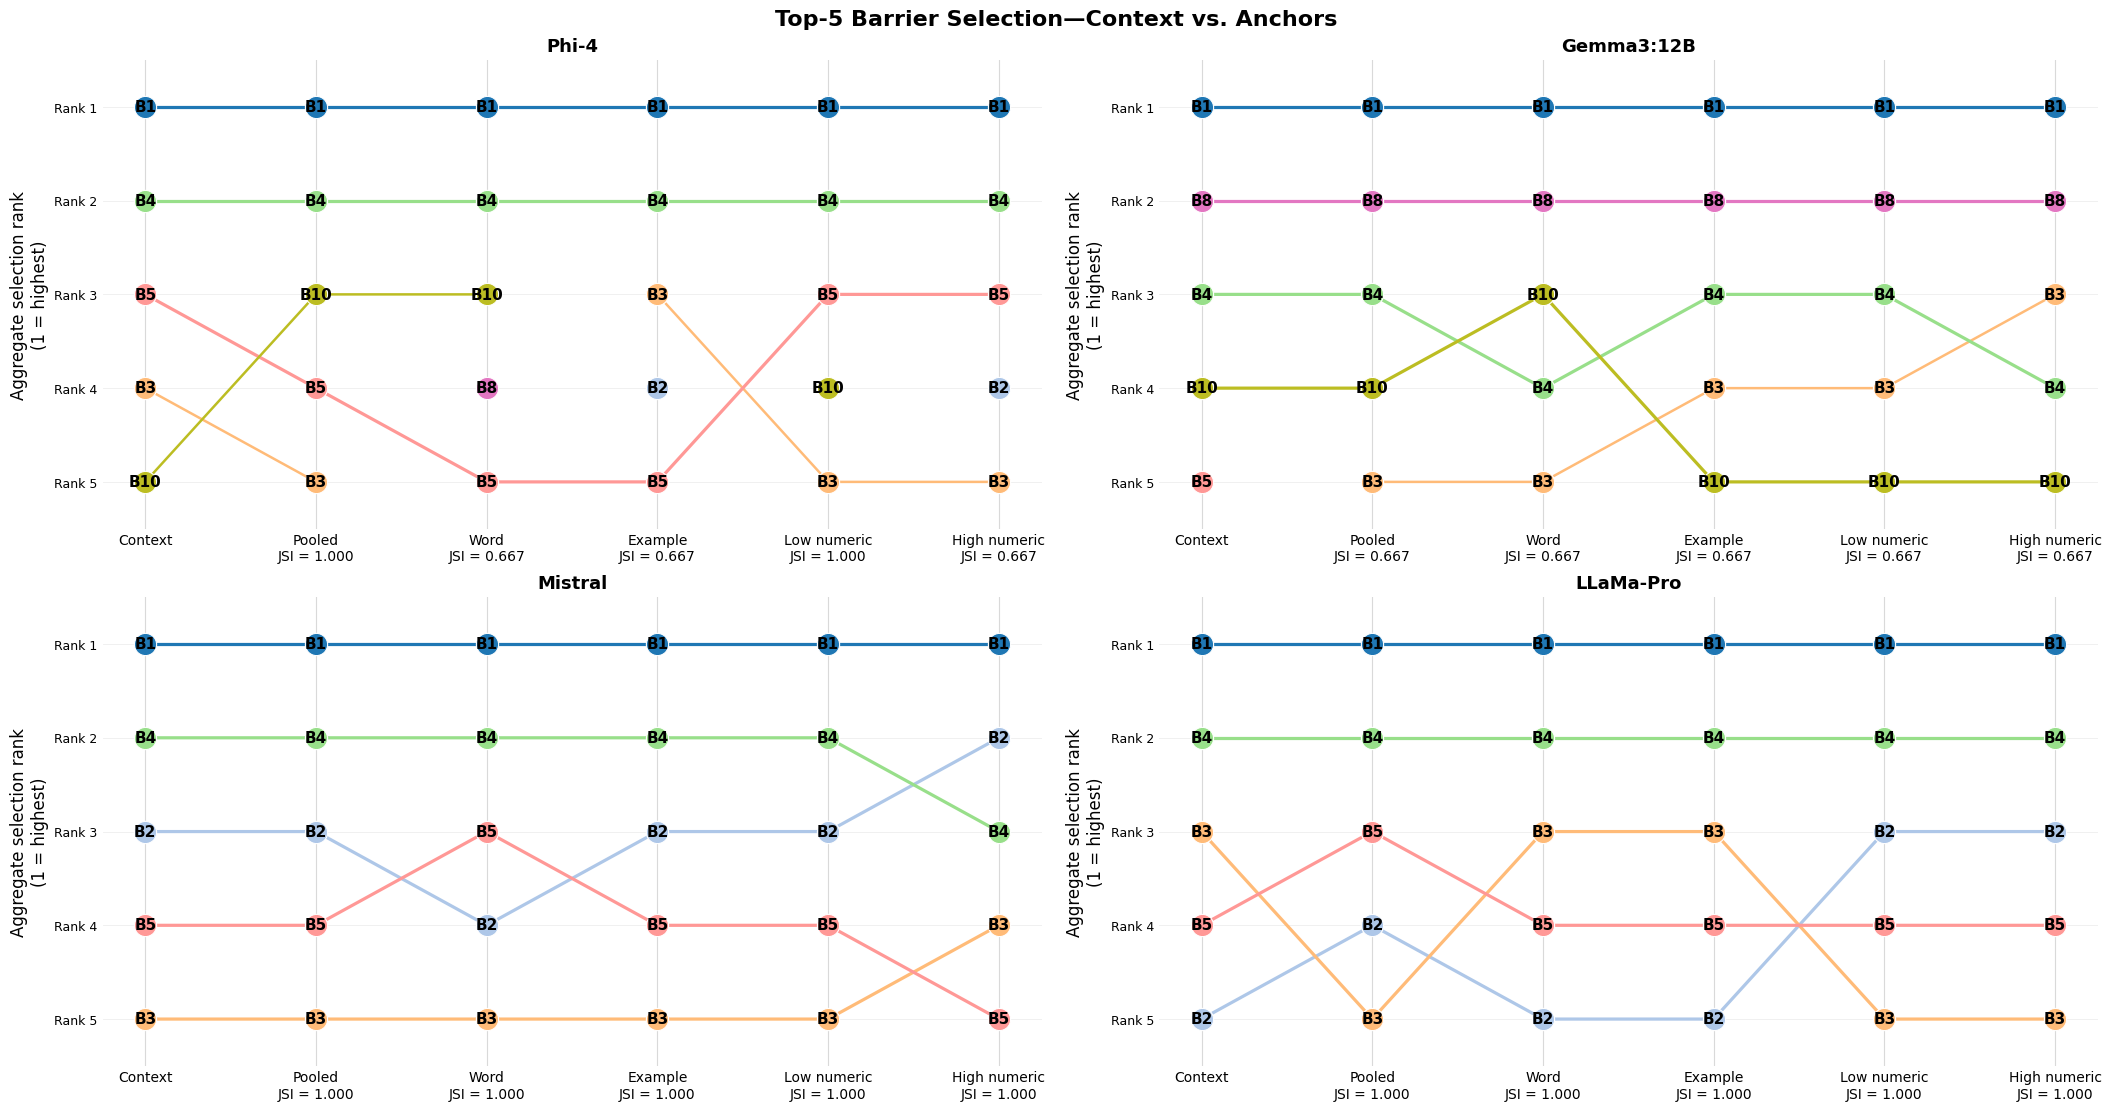

In [4]:
# RQ3 top-5 barrier slopegraph ordered by aggregate selection rank

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

working_dir = Path("barriers-ctx-anchor-working")

jaccard_input_path = (
    working_dir / "rq3_top5_jaccard_wide.csv"
)

rates_input_path = (
    working_dir
    / "rq3_selection_rates_by_base_family_and_arm.csv"
)

png_output_path = (
    working_dir / "rq3-top5-barrier-rank-slopegraph.png"
)

eps_output_path = (
    working_dir / "rq3-top5-barrier-rank-slopegraph.eps"
)

for path in [jaccard_input_path, rates_input_path]:
    if not path.exists():
        raise FileNotFoundError(
            f"Required RQ3 barrier output was not found:\n"
            f"{path.resolve()}"
        )

jaccard_results = pd.read_csv(jaccard_input_path)
selection_rates = pd.read_csv(rates_input_path)

# --------------------------------------------------------------
# Ordering and labels
# --------------------------------------------------------------

family_order = [
    "phi4",
    "gemma3",
    "mistral",
    "llama",
]

model_labels = {
    "gemma3": "Gemma3:12B",
    "llama": "LLaMa-Pro",
    "mistral": "Mistral",
    "phi4": "Phi-4",
}

# Displayed columns and their names in the selection-rate CSV
arm_rate_names = {
    "Context": "context",
    "Word": "word",
    "Example": "example",
    "Low numeric": "low-numeric",
    "High numeric": "high-numeric",
}

# Columns used only to verify membership
arm_set_columns = {
    "Context": "context_top5",
    "Pooled": "pooled_anchors_top5",
    "Word": "word_top5",
    "Example": "example_top5",
    "Low numeric": "low_numeric_top5",
    "High numeric": "high_numeric_top5",
}

jaccard_columns = {
    "Pooled": "jaccard_pooled",
    "Word": "jaccard_word",
    "Example": "jaccard_example",
    "Low numeric": "jaccard_low_numeric",
    "High numeric": "jaccard_high_numeric",
}

arm_names = [
    "Context",
    "Pooled",
    "Word",
    "Example",
    "Low numeric",
    "High numeric",
]

required_rate_columns = {
    "family",
    "arm",
    "barrier_id",
    "selection_rate",
}

missing_rate_columns = (
    required_rate_columns.difference(selection_rates.columns)
)

if missing_rate_columns:
    raise ValueError(
        "Selection-rate CSV is missing columns: "
        + ", ".join(sorted(missing_rate_columns))
    )

required_jaccard_columns = {
    "family",
    *arm_set_columns.values(),
    *jaccard_columns.values(),
}

missing_jaccard_columns = (
    required_jaccard_columns.difference(
        jaccard_results.columns
    )
)

if missing_jaccard_columns:
    raise ValueError(
        "Jaccard CSV is missing columns: "
        + ", ".join(sorted(missing_jaccard_columns))
    )

if set(jaccard_results["family"]) != set(family_order):
    raise ValueError(
        "The expected four base-model families were not found."
    )

selection_rates["barrier_id"] = pd.to_numeric(
    selection_rates["barrier_id"],
    errors="raise",
).astype(int)

selection_rates["selection_rate"] = pd.to_numeric(
    selection_rates["selection_rate"],
    errors="raise",
)

# --------------------------------------------------------------
# Helper functions
# --------------------------------------------------------------

def barrier_code(barrier_id):
    return f"B{int(barrier_id)}"


def parse_top5_set(value):
    """Parse a stored top-5 list as a set; order is ignored."""
    barriers = {
        item.strip().upper()
        for item in str(value).split(",")
        if item.strip()
    }

    if len(barriers) != 5:
        raise ValueError(
            f"Expected five distinct barriers, found: {value}"
        )

    return barriers


def obtain_top5_ranks(data, score_column):
    """
    Rank barriers by descending aggregate selection rate.
    Barrier ID is used only to resolve ties.
    """
    ranked = (
        data
        .sort_values(
            [score_column, "barrier_id"],
            ascending=[False, True],
        )
        .head(5)
        .copy()
    )

    if len(ranked) != 5:
        raise ValueError(
            "A family-arm group did not contain five barriers."
        )

    ranked["rank"] = np.arange(1, 6)

    return {
        barrier_code(row.barrier_id): int(row.rank)
        for row in ranked.itertuples()
    }


colour_map = {
    f"B{barrier_id}": plt.colormaps["tab20"](
        (barrier_id - 1) / 11
    )
    for barrier_id in range(1, 12)
}

# --------------------------------------------------------------
# Create rank-based slopegraph
# --------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(21, 11),
    constrained_layout=True,
)

axes = axes.flatten()
x_positions = np.arange(len(arm_names))

for axis, family in zip(axes, family_order):

    family_rates = selection_rates.loc[
        selection_rates["family"].eq(family)
    ].copy()

    family_row = jaccard_results.loc[
        jaccard_results["family"].eq(family)
    ].iloc[0]

    # Aggregate selection ranks for Context and each anchor arm
    rank_positions = {}

    for display_name, source_arm in arm_rate_names.items():
        arm_data = family_rates.loc[
            family_rates["arm"].eq(source_arm)
        ]

        rank_positions[display_name] = obtain_top5_ranks(
            arm_data,
            "selection_rate",
        )

    # Pooled anchors: equal weight for each of the four anchor arms,
    # matching the logic in barrier-select-rq3.R
    pooled_rates = (
        family_rates.loc[
            family_rates["arm"].ne("context")
        ]
        .groupby("barrier_id", as_index=False)
        .agg(
            pooled_selection_rate=(
                "selection_rate",
                "mean",
            )
        )
    )

    rank_positions["Pooled"] = obtain_top5_ranks(
        pooled_rates,
        "pooled_selection_rate",
    )

    # Confirm that the newly ranked sets match the Jaccard input
    for arm_name in arm_names:
        expected_set = parse_top5_set(
            family_row[arm_set_columns[arm_name]]
        )

        ranked_set = set(rank_positions[arm_name])

        if ranked_set != expected_set:
            raise ValueError(
                f"Top-5 membership mismatch for "
                f"{family}, {arm_name}.\n"
                f"Ranked from rates: {sorted(ranked_set)}\n"
                f"Stored Jaccard set: {sorted(expected_set)}"
            )

    barrier_union = sorted(
        set().union(
            *[
                set(rank_positions[arm_name])
                for arm_name in arm_names
            ]
        ),
        key=lambda value: int(value.replace("B", "")),
    )

    for barrier in barrier_union:
        y_values = [
            rank_positions[arm_name].get(
                barrier,
                np.nan,
            )
            for arm_name in arm_names
        ]

        selected_count = np.sum(
            ~np.isnan(y_values)
        )

        line_width = (
            2.3
            if selected_count == len(arm_names)
            else 1.8
        )

        axis.plot(
            x_positions,
            y_values,
            color=colour_map[barrier],
            linewidth=line_width,
            marker="o",
            markersize=16,
            markeredgecolor="white",
            markeredgewidth=0.8,
            solid_capstyle="round",
            zorder=2,
        )

        for x_value, y_value in zip(
            x_positions,
            y_values,
        ):
            if np.isnan(y_value):
                continue

            axis.text(
                x_value,
                y_value,
                barrier,
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="black",
                zorder=3,
            )

    # Add JSI values beneath the comparison labels
    x_labels = ["Context"]

    for arm_name in arm_names[1:]:
        jaccard = float(
            family_row[jaccard_columns[arm_name]]
        )

        x_labels.append(
            f"{arm_name}\nJSI = {jaccard:.3f}"
        )

    axis.set_xticks(
        x_positions,
        x_labels,
        fontsize=10,
    )

    axis.set_yticks(
        range(1, 6),
        [
            f"Rank {rank}"
            for rank in range(1, 6)
        ],
        fontsize=9,
    )

    # Rank 1 appears at the top
    axis.set_ylim(5.5, 0.5)

    axis.set_xlim(
        -0.25,
        len(arm_names) - 0.75,
    )

    axis.set_title(
        model_labels[family],
        fontsize=13,
        fontweight="bold",
    )

    axis.set_ylabel(
        "Aggregate selection rank\n(1 = highest)",
        fontsize=12,
    )

    axis.grid(
        axis="x",
        color="#D9D9D9",
        linewidth=0.8,
    )

    axis.grid(
        axis="y",
        color="#EEEEEE",
        linewidth=0.6,
    )

    axis.tick_params(
        axis="both",
        length=0,
    )

    for spine in axis.spines.values():
        spine.set_visible(False)

fig.suptitle(
    "Top-5 Barrier Selection—Context vs. Anchors",
    fontsize=16,
    fontweight="bold",
)

fig.savefig(
    png_output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    eps_output_path,
    format="eps",
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
)

print(
    "RQ3 rank-based barrier slopegraph saved to:\n"
    f"{png_output_path.resolve()}\n"
    f"{eps_output_path.resolve()}"
)

plt.show()